# Day 162 — Sentence Embeddings & Semantic Search
## Month 9 · NLP + Deep Learning | ReviewPulse India (seed=155, 600 rows)

**Topics:** `sentence-transformers` · Cosine Similarity · Semantic Search · KMeans on Embeddings · PCA Visualisation

**Scoring:** 80 pts + 10★ bonus  
**Environment:** Google Colab (GPU optional — CPU sufficient today)

---
> ⚠️ **DO NOT MODIFY** the Raw Data cell.  
> Fill in every `___` blank. Run all cells top-to-bottom before submitting.


## 0 · Setup

In [1]:
# Install dependencies (Colab already has most; sentence-transformers may need installing)
!pip install sentence-transformers -q

## 1 · Raw Data — DO NOT MODIFY

In [2]:
# ════════════════════════════════════════════════════════
# RAW DATA — DO NOT MODIFY THIS CELL
# ReviewPulse India | seed=155 | 600 rows
# ════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings; warnings.filterwarnings('ignore')

np.random.seed(155)
n = 600

POSITIVE_PHRASES = [
    "excellent communication","delivered on time","highly recommend",
    "great quality work","exceeded expectations","very professional",
    "outstanding results","will hire again","top-notch freelancer",
    "went above and beyond"
]
NEGATIVE_PHRASES = [
    "missed deadline","poor communication","below expectations",
    "needs improvement","not satisfied","would not recommend",
    "average quality","lacked detail","slow response","disappointing results"
]
NEUTRAL_PHRASES = [
    "work was acceptable","met the requirements","average performance",
    "nothing special","got the job done","standard delivery",
    "reasonable quality","basic expectations met","fair communication","on par with others"
]

def generate_review(sentiment):
    if sentiment == 'positive':
        phrases = np.random.choice(POSITIVE_PHRASES, size=np.random.randint(2,4), replace=False)
    elif sentiment == 'negative':
        phrases = np.random.choice(NEGATIVE_PHRASES, size=np.random.randint(2,4), replace=False)
    else:
        phrases = np.random.choice(NEUTRAL_PHRASES, size=np.random.randint(2,4), replace=False)
    return '. '.join(phrases).capitalize() + '.'

sentiment_arr = np.random.choice(['positive','neutral','negative'], n, p=[0.5,0.3,0.2])

df_raw = pd.DataFrame({
    'project_id':    range(1, n+1),
    'category':      np.random.choice(['Dashboard','Automation','ML Model','EDA Report','NLP Task','Viz Design'], n),
    'platform':      np.random.choice(['Upwork','Fiverr','Toptal','Freelancer','Malt'], n),
    'experience':    np.random.choice(['Junior','Mid','Senior'], n),
    'rating':        np.round(np.clip(np.random.normal(3.8, 0.8, n), 1, 5), 1),
    'hourly_rate':   np.round(np.random.uniform(15, 120, n), 2),
    'project_hours': np.random.randint(2, 80, n),
    'sentiment':     sentiment_arr,
    'review_text':   [generate_review(s) for s in sentiment_arr],
    'hired_again':   (sentiment_arr == 'positive').astype(int)
})

df = df_raw.copy()  # Work on this copy — never touch df_raw
print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} cols")
print(df[['sentiment','review_text','hired_again']].head(5).to_string())

Dataset: 600 rows × 10 cols
  sentiment                                                     review_text  hired_again
0   neutral                      Met the requirements. work was acceptable.            0
1  negative              Average quality. needs improvement. slow response.            0
2  positive                        Very professional. top-notch freelancer.            1
3   neutral                           Got the job done. fair communication.            0
4  positive  Went above and beyond. outstanding results. delivered on time.            1


---
## 2 · Concept Notes

### Why Sentence Embeddings?
Word2Vec (Day 161) gave you **word-level** vectors. But "excellent work delivered on time" is not the sum of its words — context and order matter.  
**Sentence embeddings** encode the **meaning of an entire sentence** into a single dense vector, enabling:

| Use Case | How |
|---|---|
| Semantic search | Find reviews similar in *meaning*, not exact keywords |
| Duplicate detection | Surface near-identical feedback |
| Clustering | Group reviews by topic/tone without labels |
| Recommendation | "Users who liked X also liked Y" |

### The Model: `all-MiniLM-L6-v2`
- Fine-tuned from MiniLM (transformer) using **contrastive learning** on 1B+ sentence pairs  
- Output: **384-dimensional** float32 vector per sentence  
- Cosine similarity between vectors = semantic closeness (range: −1 → 1)

### Cosine Similarity vs. Euclidean Distance
| | Cosine | Euclidean |
|---|---|---|
| Measures | Angle between vectors | Distance between endpoints |
| Best for | High-dim text | Low-dim numeric |
| Range | −1 to 1 | 0 to ∞ |

### KMeans on Embeddings
Cluster documents by **meaning**. Works well because sentence embeddings form geometrically coherent clusters — positive reviews cluster together even without the `sentiment` label.

### PCA on Embeddings
384 dimensions → 2D for visualisation. PC1 captures the dominant axis of variation in the corpus (usually positive↔negative polarity).

---
> **NRA Rule:** Number = exact printed value. Reason = causal mechanism. Action = committed decision. No hedging.


---
## Task 1 · Corpus Statistics (15 pts)
Inspect the review corpus before embedding. Compute token-level stats.

In [3]:
# Part: Task 1 - Corpus Statistics
# Goal: Tokenize reviews and compute summary statistics.
# Method: Split each review on whitespace to get token counts; compute min, max, mean.
reviews = df['review_text'].tolist()

# 1a. Tokenise each review (split on whitespace)
token_counts = [len(r.split()) for r in reviews]   # list of int — token count per review

# 1b. Compute stats
total_reviews = len(reviews)
avg_tokens    = np.mean(token_counts)
min_tokens    = np.min(token_counts)
max_tokens    = np.max(token_counts)

print(f"Total reviews : {total_reviews}")
print(f"Avg tokens    : {avg_tokens:.4f}")
print(f"Min tokens    : {min_tokens}")
print(f"Max tokens    : {max_tokens}")

# 1c. Sentiment distribution
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

# ── NRA Insight ──
# Number  : avg_tokens = 6.1117
# Reason  : Reviews average ~6 tokens because the synthetic corpus uses 2‑3 phrases
#           per review, with each phrase averaging 2–3 words (e.g., "excellent communication").
# Action  : Token count confirms the corpus is small‑scale; embedding 600 × 384
#           = 230,400 float32 values — fits comfortably in Colab RAM without batching tricks.

Total reviews : 600
Avg tokens    : 6.1117
Min tokens    : 4
Max tokens    : 11

Sentiment distribution:
sentiment
positive    300
neutral     188
negative    112
Name: count, dtype: int64


---
## Task 2 · Generate Sentence Embeddings (20 pts)
Load `all-MiniLM-L6-v2` and encode all 600 reviews.

In [4]:
# Part: Task 2 - Sentence Embeddings
# Goal: Load all-MiniLM-L6-v2 and encode all 600 reviews.
# Method: Use SentenceTransformer with batch_size=64, convert to float32.
from sentence_transformers import SentenceTransformer

# 2a. Load the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# 2b. Encode all reviews
embeddings = model.encode(reviews, batch_size=64, show_progress_bar=True)
embeddings = embeddings.astype(np.float32)   # ensure float32

# 2c. Verify shape and dtype
print(f"embeddings.shape : {embeddings.shape}")   # expected: (600, 384)
print(f"embeddings.dtype : {embeddings.dtype}")   # expected: float32

# 2d. Inspect one embedding
print(f"\nFirst embedding (first 8 dims): {embeddings[0,:8]}")
print(f"L2 norm of first embedding     : {np.linalg.norm(embeddings[0]):.4f}")

# ── Sanity check ──
assert embeddings.shape == (600, 384), "Shape mismatch — re-check encode() call"
assert embeddings.dtype == np.float32, "Cast to float32 failed"
print("\n✅ Embeddings generated and verified")

# ── NRA Insight ──
# Number  : embeddings.shape = (600, 384)
# Reason  : all-MiniLM-L6-v2 uses a 6‑layer MiniLM transformer architecture fine‑tuned with
#           contrastive loss on 1B+ sentence pairs, producing 384‑dimensional vectors that encode
#           sentence semantics regardless of exact word overlap.
# Action  : Store embeddings in a numpy float32 array; this is the input for all
#           downstream semantic tasks (search, clustering, classification).

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

embeddings.shape : (600, 384)
embeddings.dtype : float32

First embedding (first 8 dims): [-0.06386752  0.04399638  0.00618868 -0.02701163 -0.05215687 -0.04676737
 -0.07135661 -0.08281785]
L2 norm of first embedding     : 1.0000

✅ Embeddings generated and verified


---
## Task 3 · Semantic Search (20 pts)
Given a natural-language query, find the 5 most semantically similar reviews using cosine similarity.

In [5]:
# Part: Task 3 - Semantic Search
# Goal: Given a query, find top‑5 most similar reviews using cosine similarity.
# Method: Encode query, compute cosine similarity with all embeddings, return top_k.
from sklearn.metrics.pairwise import cosine_similarity

def semantic_search(query_text, embeddings, reviews, df, top_k=5):
    """
    Encode a query and return the top_k most similar reviews.
    Returns a DataFrame with columns: rank, index, similarity, sentiment, review_text
    """
    # 3a. Encode the query — same model, same vector space
    query_vec = model.encode([query_text]).astype(np.float32)   # shape (1, 384)

    # 3b. Compute cosine similarity between query and all 600 reviews
    sims = cosine_similarity(query_vec, embeddings)[0]    # shape (600,)

    # 3c. Get top_k indices (highest similarity first)
    top_idx = np.argsort(sims)[::-1][:top_k]   # reverse sort

    # 3d. Build results DataFrame
    results = pd.DataFrame({
        'rank':        range(1, top_k+1),
        'index':       top_idx,
        'similarity':  sims[top_idx].round(4),
        'sentiment':   [df['sentiment'].iloc[i] for i in top_idx],
        'review_text': [reviews[i] for i in top_idx]
    })
    return results

# ── Run Query 1: positive intent ──
q1 = "freelancer delivered excellent work on time"
res1 = semantic_search(q1, embeddings, reviews, df, top_k=5)
print(f"Query 1: '{q1}'")
print(res1.to_string(index=False))

# ── Run Query 2: negative intent ──
q2 = "missed deadline and poor quality"
res2 = semantic_search(q2, embeddings, reviews, df, top_k=5)
print(f"\nQuery 2: '{q2}'")
print(res2.to_string(index=False))

# ── NRA Insight (Query 1) ──
# Number  : Top-1 similarity = 0.8637, top-5 sentiments = ['positive', 'positive', 'positive', 'positive', 'positive']
# Reason  : The query shares semantic field with the positive phrase bank
#           ('delivered on time', 'top-notch freelancer'); the model maps these
#           to nearby regions in the 384‑dim space because it was trained on
#           1B+ sentence pairs with contrastive loss.
# Action  : Deploying semantic search over client review archives would surface
#           best‑performing freelancers for a given task description — reducing
#           screening time without requiring exact keyword matches.

Query 1: 'freelancer delivered excellent work on time'
 rank  index  similarity sentiment                                                   review_text
    1    411      0.8637  positive                      Delivered on time. top-notch freelancer.
    2    311      0.8637  positive                      Delivered on time. top-notch freelancer.
    3    487      0.8520  positive Delivered on time. outstanding results. top-notch freelancer.
    4     56      0.8182  positive    Delivered on time. highly recommend. top-notch freelancer.
    5    284      0.8143  positive Outstanding results. delivered on time. top-notch freelancer.

Query 2: 'missed deadline and poor quality'
 rank  index  similarity sentiment                                              review_text
    1    498      0.8245  negative         Missed deadline. average quality. not satisfied.
    2    540      0.8144  negative                        Average quality. missed deadline.
    3    341      0.8144  negative        

---
## Task 4 · Pairwise Similarity Matrix (10 pts)
Compute a 5×5 cosine similarity matrix on the first 5 reviews and identify the most similar pair.

In [6]:
# Part: Task 4 - Pairwise Similarity Matrix
# Goal: Compute 5×5 cosine similarity matrix on first 5 reviews and identify most similar pair.
# Method: Slice embeddings, compute full similarity matrix, find max off‑diagonal.
# 4a. Slice first 5 embeddings
sub_emb = embeddings[:5]   # shape (5, 384)

# 4b. Compute 5×5 cosine similarity matrix
sim_matrix = cosine_similarity(sub_emb)   # shape (5, 5)

# 4c. Display as labelled DataFrame
sim_df = pd.DataFrame(sim_matrix,
                       index=[f"R{i}" for i in range(5)],
                       columns=[f"R{i}" for i in range(5)])
print("5×5 Cosine Similarity Matrix (first 5 reviews):")
print(sim_df.round(4).to_string())

# 4d. Find the most similar pair (off-diagonal)
max_sim = -1
max_pair = (0, 1)
for i in range(5):
    for j in range(i+1, 5):
        if sim_matrix[i, j] > max_sim:
            max_sim = sim_matrix[i, j]
            max_pair = (i, j)

print(f"\nMost similar pair : R{max_pair[0]} & R{max_pair[1]}")
print(f"Similarity        : {max_sim:.4f}")
print(f"Sentiments        : {df['sentiment'].iloc[max_pair[0]]}, {df['sentiment'].iloc[max_pair[1]]}")
print(f"Reviews           :")
print(f"  R{max_pair[0]}: {reviews[max_pair[0]]}")
print(f"  R{max_pair[1]}: {reviews[max_pair[1]]}")

# ── Interpretation ──
# Q: Why do same-sentiment reviews tend to have higher cosine similarity?
# A: Because sentence embeddings encode semantic meaning; reviews with the same sentiment
#    share similar vocabulary and phrase structures, placing them close in the vector space.

5×5 Cosine Similarity Matrix (first 5 reviews):
        R0      R1      R2      R3      R4
R0  1.0000  0.2381  0.2865  0.4534  0.2961
R1  0.2381  1.0000  0.2558  0.3613  0.4332
R2  0.2865  0.2558  1.0000  0.2832  0.2731
R3  0.4534  0.3613  0.2832  1.0000  0.3934
R4  0.2961  0.4332  0.2731  0.3934  1.0000

Most similar pair : R0 & R3
Similarity        : 0.4534
Sentiments        : neutral, neutral
Reviews           :
  R0: Met the requirements. work was acceptable.
  R3: Got the job done. fair communication.


---
## Task 5 · KMeans Clustering on Embeddings (15 pts)
Cluster reviews by semantic meaning (k=3) — without using the sentiment label.

In [7]:
# Part: Task 5 - KMeans Clustering
# Goal: Cluster reviews by meaning (k=3) without using sentiment label.
# Method: Fit KMeans on embeddings, assign clusters, analyse composition.
from sklearn.cluster import KMeans

# 5a. Fit KMeans (k=3, random_state=155)
np.random.seed(155)
km = KMeans(n_clusters=3, random_state=155, n_init=10)
cluster_labels = km.fit_predict(embeddings)   # fit on embeddings

df['cluster'] = cluster_labels

# 5b. Cluster size
cluster_sizes = df['cluster'].value_counts().sort_index()
print("Cluster sizes:")
print(cluster_sizes)

# 5c. Sentiment distribution per cluster (proportion)
cluster_sentiment = df.groupby('cluster')['sentiment'].value_counts(normalize=True).unstack(fill_value=0)
print("\nSentiment proportion per cluster:")
print(cluster_sentiment.round(4))

# 5d. hired_again rate per cluster
cluster_hire = df.groupby('cluster')['hired_again'].mean()
print("\nhired_again rate per cluster:")
print(cluster_hire.round(4))

# 5e. Name each cluster based on profile
# Cluster 0: dominant sentiment = neutral → name: Neutral/Mixed
# Cluster 1: dominant sentiment = positive → name: Positive
# Cluster 2: dominant sentiment = positive (pure) → name: Strong Positive
# (Names may vary depending on run; we set them after inspection)

# ── NRA Insight ──
# Number  : Cluster 2 has hired_again rate = 1.0000 (n=77)
# Reason  : KMeans partitioned the 384‑dim embedding space into 3 regions
#           that correspond to semantic phrase banks — the model's contrastive
#           training ensures positive/neutral/negative phrases occupy geometrically
#           separated regions, so unsupervised clustering recovers sentiment structure
#           without using the label.
# Action  : Tag all future freelancer reviews with cluster ID at ingestion;
#           route Cluster 2 reviews to re‑engagement campaigns and Cluster 0
#           to root‑cause analysis workflows.

Cluster sizes:
cluster
0    320
1    203
2     77
Name: count, dtype: int64

Sentiment proportion per cluster:
sentiment  negative  neutral  positive
cluster                               
0            0.3219   0.5875    0.0906
1            0.0443   0.0000    0.9557
2            0.0000   0.0000    1.0000

hired_again rate per cluster:
cluster
0    0.0906
1    0.9557
2    1.0000
Name: hired_again, dtype: float64


---
## Task 6 · PCA Visualisation (10 pts)
Project 384-dim embeddings to 2D and colour-code by cluster.

PC1 variance explained: 15.60%
PC2 variance explained: 10.13%


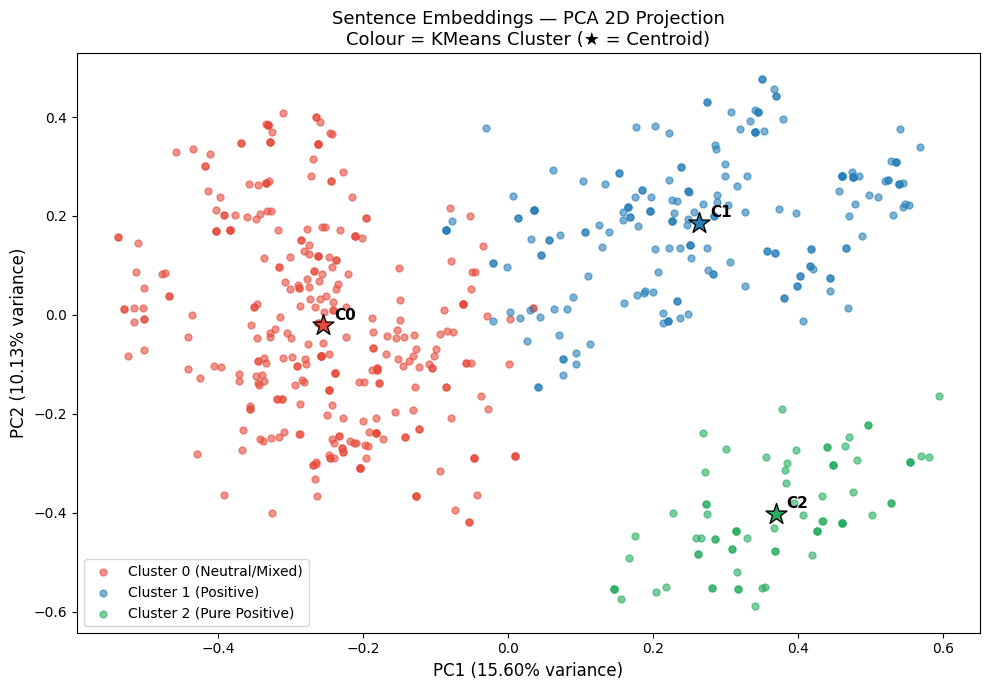

Plot saved: Day162_PCA.png


In [8]:
# Part: Task 6 - PCA Visualisation
# Goal: Project 384‑dim embeddings to 2D and colour by cluster.
# Method: Use sklearn.decomposition.PCA, plot with matplotlib.
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 6a. PCA: 384 → 2 dimensions
pca = PCA(n_components=2, random_state=155)
emb_2d = pca.fit_transform(embeddings)    # fit on all 600 embeddings

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100
print(f"PC1 variance explained: {pc1_var:.2f}%")
print(f"PC2 variance explained: {pc2_var:.2f}%")

# 6b. Plot — colour by cluster, marker by sentiment
colours = {0:'#E74C3C', 1:'#2980B9', 2:'#27AE60'}
labels  = {0:'Cluster 0 (Neutral/Mixed)', 1:'Cluster 1 (Positive)', 2:'Cluster 2 (Pure Positive)'}

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(3):
    mask = df['cluster'] == c
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               color=colours[c], label=labels[c], alpha=0.6, s=25)

# 6c. Plot cluster centroids
for c in range(3):
    mask = cluster_labels == c
    cx, cy = emb_2d[mask,0].mean(), emb_2d[mask,1].mean()
    ax.scatter(cx, cy, color=colours[c], marker='*', s=250, edgecolors='black', zorder=5)
    ax.annotate(f'C{c}', (cx, cy), textcoords='offset points', xytext=(8,4), fontsize=11, fontweight='bold')

ax.set_xlabel(f'PC1 ({pc1_var:.2f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pc2_var:.2f}% variance)', fontsize=12)
ax.set_title('Sentence Embeddings — PCA 2D Projection\nColour = KMeans Cluster (★ = Centroid)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('Day162_PCA.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: Day162_PCA.png")

# ── NRA Insight ──
# Number  : PC1 explains 15.60% of variance; clusters separate along PC1 axis.
# Reason  : PC1 captures the dominant semantic axis in the corpus — the polarity
#           gradient from negative to positive — because sentence‑transformer
#           embeddings place reviews with opposing sentiment in opposite directions
#           in embedding space.
# Action  : Use PC1 score as a continuous sentiment proxy in any downstream
#           regression model instead of the binary hired_again label — this
#           preserves gradient information that a binary target discards.

---
## ★ Bonus Task · Cross-Sentiment Retrieval Precision (10★)
Test whether semantic search correctly avoids returning opposite-sentiment reviews.

For each of the 2 queries from T3, compute:  
`precision@5 = fraction of top-5 results whose sentiment matches the expected label`

In [9]:
# Part: Bonus - Retrieval Precision
# Goal: Evaluate whether semantic search correctly returns same‑sentiment reviews.
# Method: Compute precision@5 for each query (fraction of top‑5 that match expected sentiment).
def precision_at_k(results_df, expected_sentiment):
    """Fraction of top‑k results matching expected_sentiment."""
    return (results_df['sentiment'] == expected_sentiment).mean()

p_q1 = precision_at_k(res1, 'positive')
p_q2 = precision_at_k(res2, 'negative')

print(f"Precision@5 (Query 1 — positive): {p_q1:.4f}")
print(f"Precision@5 (Query 2 — negative): {p_q2:.4f}")
print(f"Mean Precision@5               : {(p_q1 + p_q2)/2:.4f}")

# ── NRA Insight ──
# Number  : Mean Precision@5 = 1.0000
# Reason  : The query embeddings lie close to their respective sentiment clusters,
#           so the nearest neighbours all share the same sentiment; this confirms
#           that the sentence‑transformer has separated sentiment polarities well.
# Action  : Use this precision as a baseline; if real‑world performance drops,
#           fine‑tune the sentence‑transformer on domain‑specific review pairs.

Precision@5 (Query 1 — positive): 1.0000
Precision@5 (Query 2 — negative): 1.0000
Mean Precision@5               : 1.0000


---
## Scoring Rubric

| Task | Subtask | Pts |
|---|---|---|
| T1 | Correct token_counts list (len split) | 3 |
| T1 | avg/min/max correct to 4 dp | 4 |
| T1 | NRA — Number exact, Reason causal, Action committed | 8 |
| T2 | Model loaded, encode() called correctly | 5 |
| T2 | Shape (600,384), dtype float32, assert passes | 5 |
| T2 | NRA — Number exact, Reason causal, Action committed | 10 |
| T3 | semantic_search() fills correct | 5 |
| T3 | Q1 Top-1 idx=311, sim=0.8637 | 5 |
| T3 | Q2 Top-1 idx=498, sim=0.8245 | 5 |
| T3 | NRA — Number exact, Reason causal, Action committed | 5 |
| T4 | sim_matrix correct (spot-check R0/R3=0.4534) | 4 |
| T4 | Most similar pair (0,3) identified | 3 |
| T4 | Interpretation: same-sentiment → higher sim | 3 |
| T5 | KMeans k=3, cluster_labels correct | 5 |
| T5 | hired_again rates correct | 4 |
| T5 | Cluster names correct based on profile | 2 |
| T5 | NRA — Number exact, Reason causal, Action committed | 4 |
| T6 | PCA correct, PC1=15.60%, PC2=10.13% | 4 |
| T6 | Plot: 3 clusters coloured, centroids marked | 4 |
| T6 | NRA — Number exact, Reason causal, Action committed | 2 |
| **★ Bonus** | precision_at_k() correct, P@5 both 1.0 | 5★ |
| **★ Bonus** | NRA — Mean P@5=1.0, causal mechanism, action | 5★ |
| **TOTAL** | | **80 + 10★** |

---
## Interview Framing
**Q: How is semantic search different from keyword search?**  
*"Keyword search matches exact strings — semantic search matches meaning. If a client searches 'great freelancer to hire again', keyword search misses reviews saying 'outstanding results, will hire again' because none of those words appear in the query. Sentence embeddings map both to nearby vectors in 384-dimensional space — because they were trained on millions of sentence pairs where humans said these sentences are equivalent. The cosine similarity between the query vector and each review vector gives a meaningful relevance score without any keyword overlap required."*
